In [19]:
#1. Data Loading and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")

print("--- Aperçu des données ---")
print(df.head())

print("\n--- Informations sur le Dataset ---")
print(df.info())

print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())


# Gestion des dates
df['Date'] = pd.to_datetime(df['Date'],format="%d/%m/%Y")

df = df.sort_values('Date')
df.set_index('Date', inplace=True)
print(f"Données du {df.index.min()} au {df.index.max()}")


--- Aperçu des données ---
         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200

--- Informations sur le Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1),

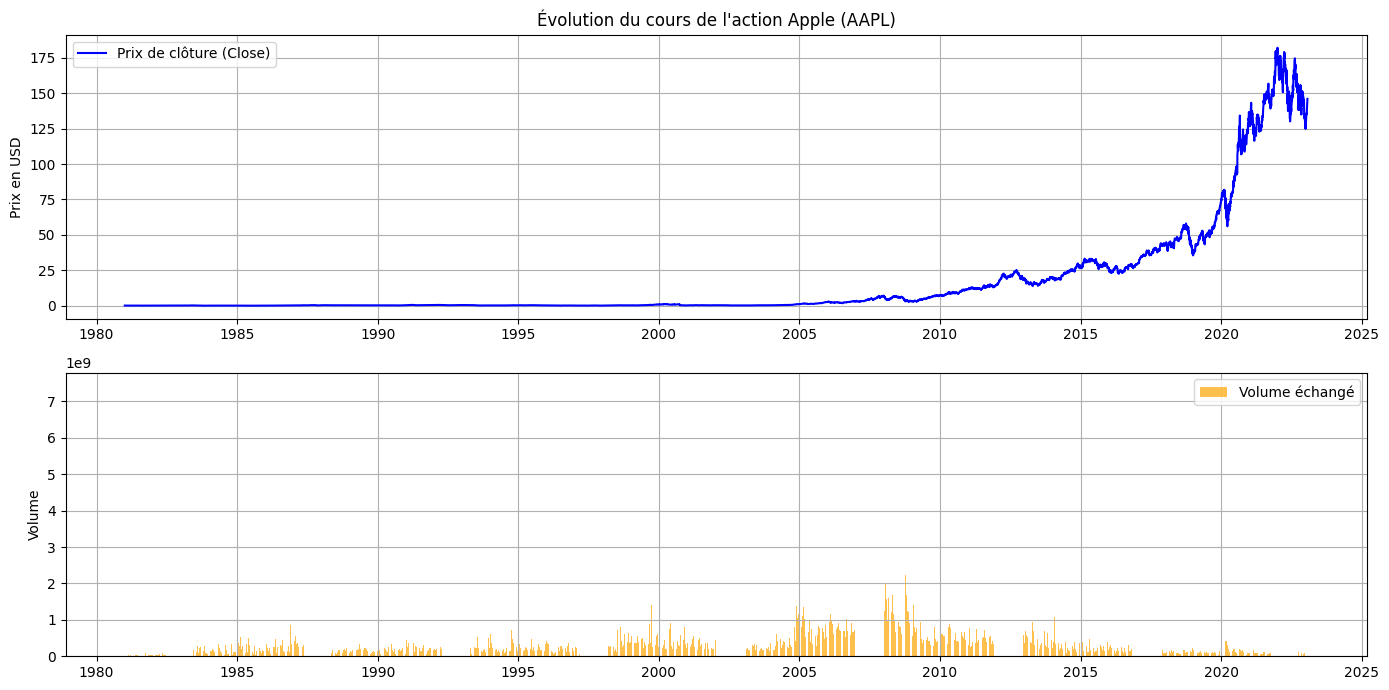

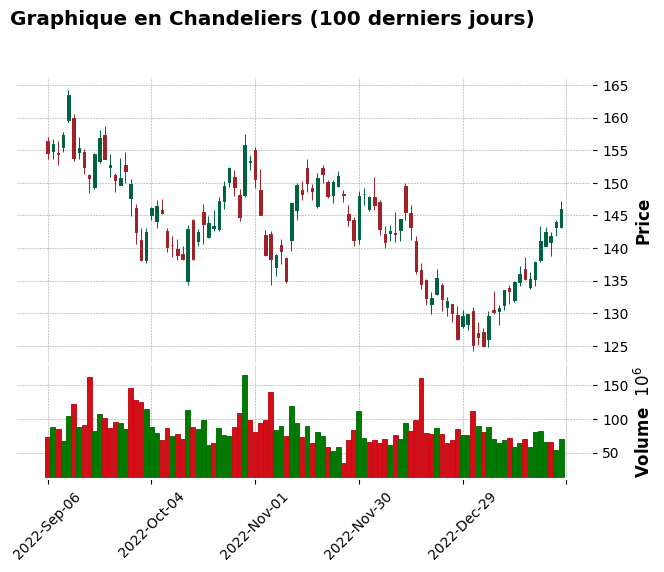

In [13]:
#Étape 2 : Visualisation des données
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Prix de clôture (Close)', color='blue')
plt.title("Évolution du cours de l'action Apple (AAPL)")
plt.ylabel('Prix en USD')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.bar(df.index, df['Volume'], label='Volume échangé', color='orange', alpha=0.7)
plt.ylabel('Volume')
export_legend = plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

import mplfinance as mpf
df_recent = df.tail(100)
mpf.plot(df_recent, type='candle', style='charles', title="Graphique en Chandeliers (100 derniers jours)", volume=True)

--- Statistiques descriptives des colonnes clés ---
               Open          High           Low         Close        Volume
count  10608.000000  10608.000000  10608.000000  10608.000000  1.060800e+04
mean      16.689173     16.879955     16.500822     16.697362  3.275098e+08
std       35.450519     35.882848     35.031289     35.473912  3.378203e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.287946      0.296875      0.282355      0.288923  1.213044e+08
50%        0.488839      0.495536      0.480446      0.487701  2.145976e+08
75%       16.320893     16.418483     16.151249     16.269554  4.066804e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09

Focus sur le cours de clôture (Close) :
 - Moyenne : 16.70 USD
 - Médiane : 0.49 USD
 - Écart-type (Volatilité) : 35.47 USD


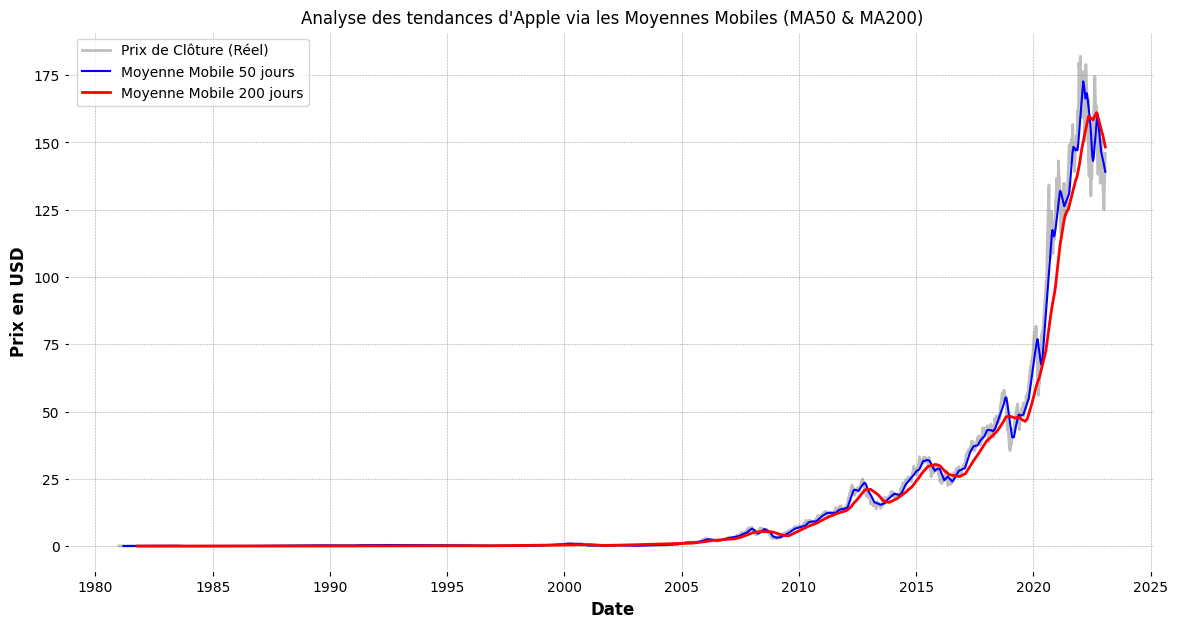

In [14]:
#Étape 3 : Analyse statistique

print("--- Statistiques descriptives des colonnes clés ---")
colonnes_cles = ['Open', 'High', 'Low', 'Close', 'Volume']
statistiques = df[colonnes_cles].describe()
print(statistiques)

moyenne_cloture = df['Close'].mean()
mediane_cloture = df['Close'].median()
ecart_type_cloture = df['Close'].std()

print(f"\nFocus sur le cours de clôture (Close) :")
print(f" - Moyenne : {moyenne_cloture:.2f} USD")
print(f" - Médiane : {mediane_cloture:.2f} USD")
print(f" - Écart-type (Volatilité) : {ecart_type_cloture:.2f} USD")

df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Prix de Clôture (Réel)', color='gray', alpha=0.5)
plt.plot(df.index, df['MA50'], label='Moyenne Mobile 50 jours', color='blue', linewidth=1.5)
plt.plot(df.index, df['MA200'], label='Moyenne Mobile 200 jours', color='red', linewidth=2)

plt.title("Analyse des tendances d'Apple via les Moyennes Mobiles (MA50 & MA200)")
plt.xlabel("Date")
plt.ylabel("Prix en USD")
plt.legend()
plt.grid(True)
plt.show()

         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200
<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB
None
Date         0
Open         

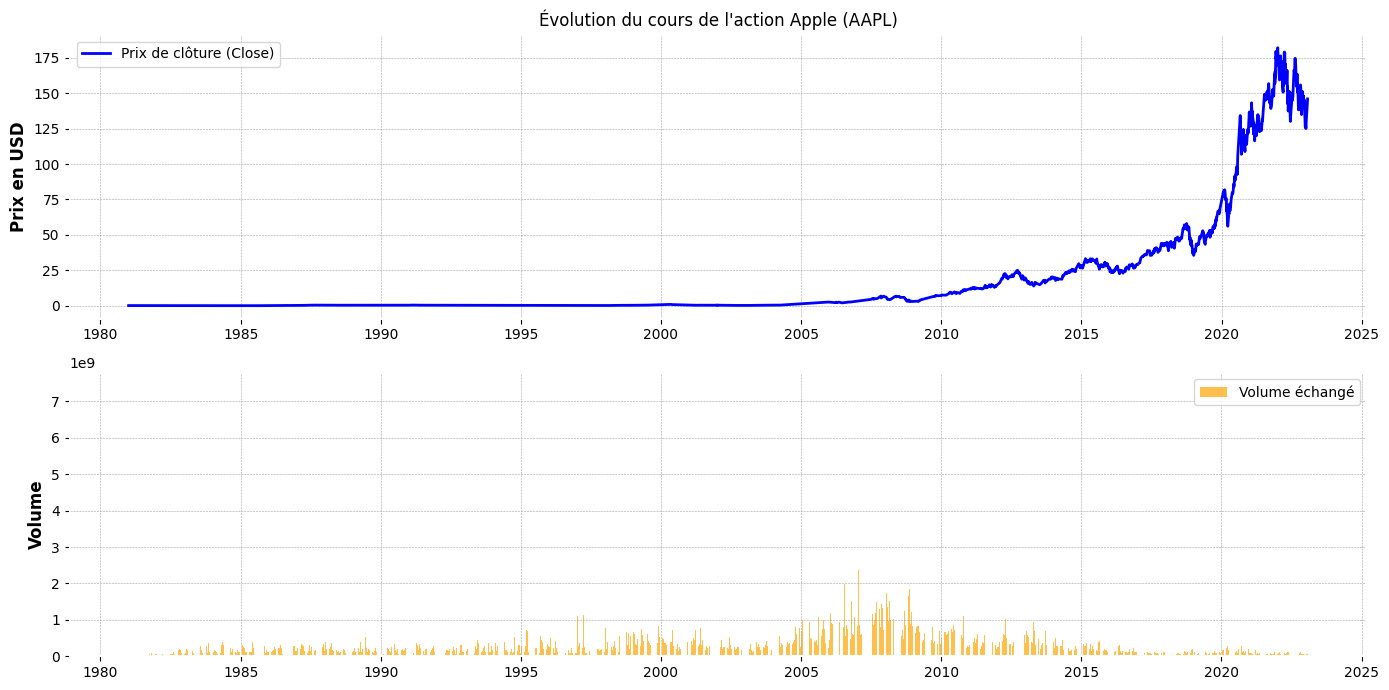

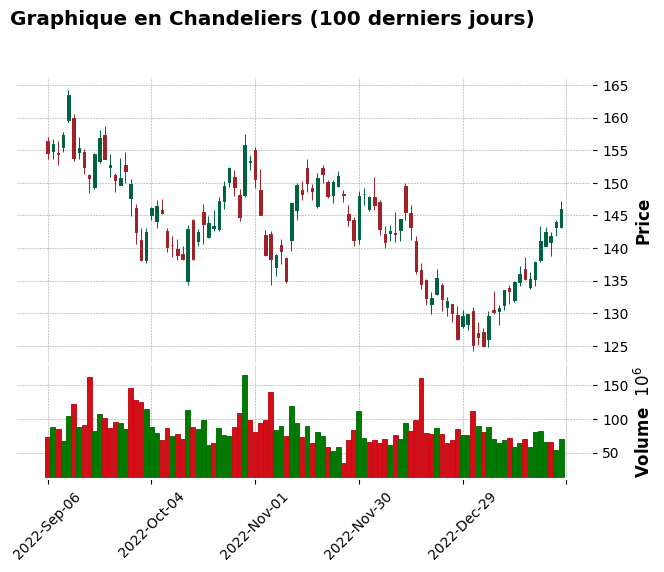

--- Statistiques descriptives des colonnes clés ---
               Open          High           Low         Close        Volume
count  10608.000000  10608.000000  10608.000000  10608.000000  1.060800e+04
mean      16.689173     16.879955     16.500822     16.697362  3.275098e+08
std       35.450519     35.882848     35.031289     35.473912  3.378203e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.287946      0.296875      0.282355      0.288923  1.213044e+08
50%        0.488839      0.495536      0.480446      0.487701  2.145976e+08
75%       16.320893     16.418483     16.151249     16.269554  4.066804e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09

Focus sur le cours de clôture (Close) :
 - Moyenne : 16.70 USD
 - Médiane : 0.49 USD
 - Écart-type (Volatilité) : 35.47 USD


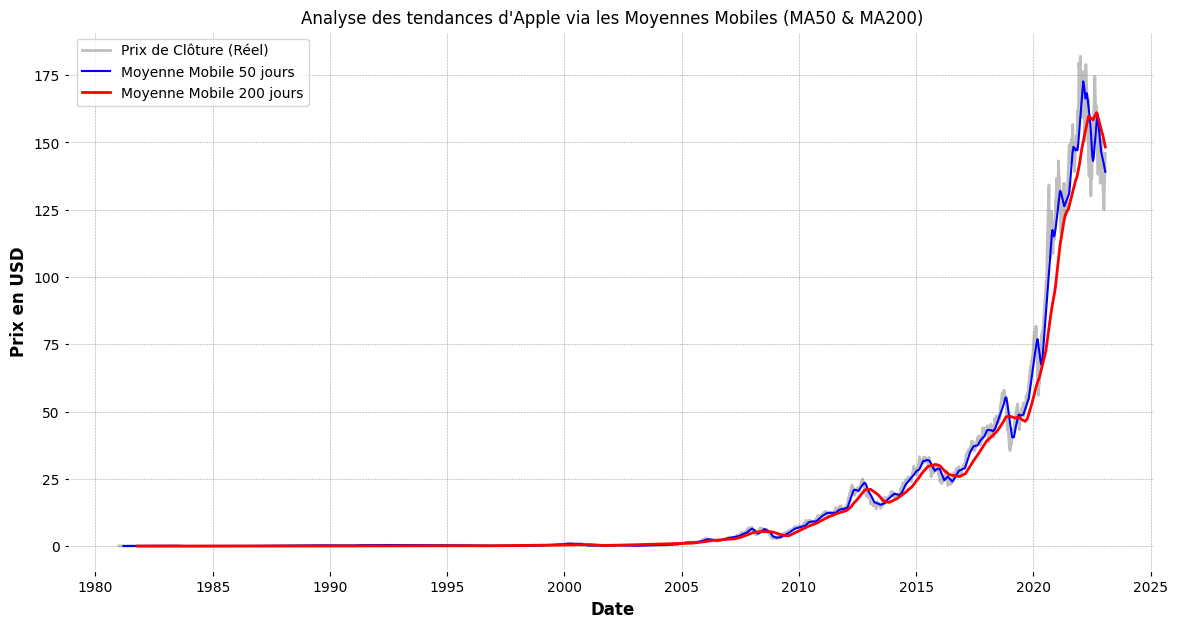

--- Test t : Comparaison des moyennes (2020 vs 2022) ---
Statistique t : -37.1855
p-value du Test t : 7.8201e-134
 Conclusion : La différence entre les moyennes est statistiquement significative (On rejette H0).

--- Test de Normalité des Rendements Quotidiens ---
Statistique de test : 2719.2053
p-value de normalité : 0.0000e+00
 Conclusion : Les rendements NE suivent PAS une loi normale (On rejette H0).


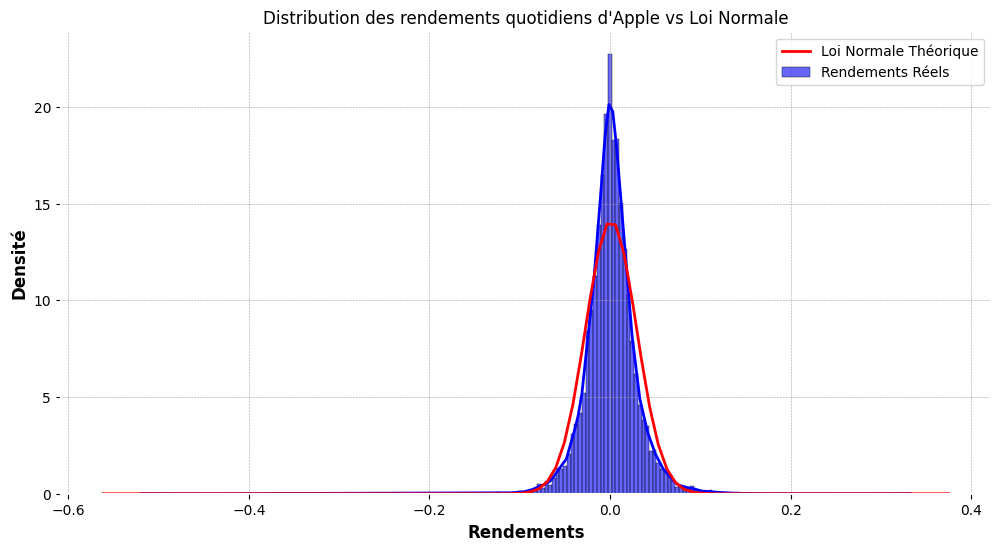

In [17]:
#Étape 4 :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mplfinance as mpf

df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'],format="%d/%m/%Y")
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

print(f"Données du {df.index.min()} au {df.index.max()}")

plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Prix de clôture (Close)', color='blue')
plt.title("Évolution du cours de l'action Apple (AAPL)")
plt.ylabel('Prix en USD')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.bar(df.index, df['Volume'], label='Volume échangé', color='orange', alpha=0.7)
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df_recent = df.tail(100)
mpf.plot(df_recent, type='candle', style='charles', title="Graphique en Chandeliers (100 derniers jours)", volume=True)

print("--- Statistiques descriptives des colonnes clés ---")
colonnes_cles = ['Open', 'High', 'Low', 'Close', 'Volume']
statistiques = df[colonnes_cles].describe()
print(statistiques)

moyenne_cloture = df['Close'].mean()
mediane_cloture = df['Close'].median()
ecart_type_cloture = df['Close'].std()

print(f"\nFocus sur le cours de clôture (Close) :")
print(f" - Moyenne : {moyenne_cloture:.2f} USD")
print(f" - Médiane : {mediane_cloture:.2f} USD")
print(f" - Écart-type (Volatilité) : {ecart_type_cloture:.2f} USD")

df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Prix de Clôture (Réel)', color='gray', alpha=0.5)
plt.plot(df.index, df['MA50'], label='Moyenne Mobile 50 jours', color='blue', linewidth=1.5)
plt.plot(df.index, df['MA200'], label='Moyenne Mobile 200 jours', color='red', linewidth=2)
plt.title("Analyse des tendances d'Apple via les Moyennes Mobiles (MA50 & MA200)")
plt.xlabel("Date")
plt.ylabel("Prix en USD")
plt.legend()
plt.grid(True)
plt.show()

df['Returns'] = df['Close'].pct_change()

prix_2020 = df.loc['2020', 'Close']
prix_2022 = df.loc['2022', 'Close']

t_stat, p_val_t = stats.ttest_ind(prix_2020, prix_2022, equal_var=False)

print("--- Test t : Comparaison des moyennes (2020 vs 2022) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value du Test t : {p_val_t:.4e}")

alpha = 0.05
if p_val_t < alpha:
    print(" Conclusion : La différence entre les moyennes est statistiquement significative (On rejette H0).")
else:
    print(" Conclusion : Pas de différence statistiquement significative (On ne peut pas rejeter H0).")

rendements_propres = df['Returns'].dropna()

stat_norm, p_val_norm = stats.normaltest(rendements_propres)

print("\n--- Test de Normalité des Rendements Quotidiens ---")
print(f"Statistique de test : {stat_norm:.4f}")
print(f"p-value de normalité : {p_val_norm:.4e}")

if p_val_norm < alpha:
    print(" Conclusion : Les rendements NE suivent PAS une loi normale (On rejette H0).")
else:
    print(" Conclusion : Les rendements suivent une loi normale (On ne peut pas rejeter H0).")

plt.figure(figsize=(12, 6))
sns.histplot(rendements_propres, kde=True, stat="density", color="blue", alpha=0.6, label="Rendements Réels")

mu, std = rendements_propres.mean(), rendements_propres.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label="Loi Normale Théorique")

plt.title("Distribution des rendements quotidiens d'Apple vs Loi Normale")
plt.xlabel("Rendements")
plt.ylabel("Densité")
plt.legend()
plt.grid(True)
plt.show()

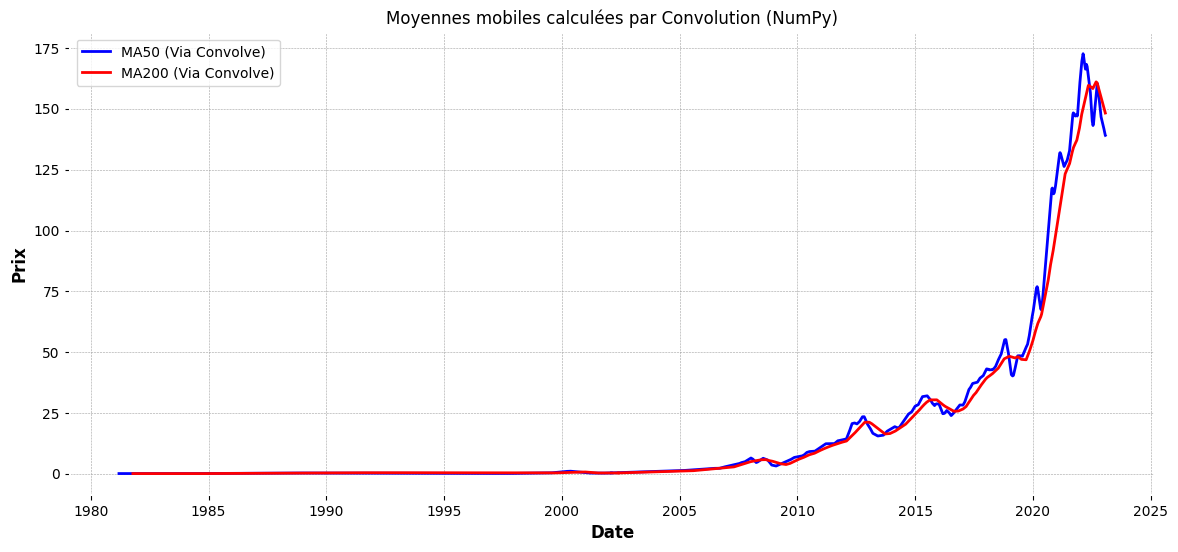

--- Analyse des Corrélations (NumPy) ---
Corrélation entre MA50 et Volume (Période courte/moyenne) : -0.2156
Corrélation entre MA200 et Volume (Période longue) : -0.2233


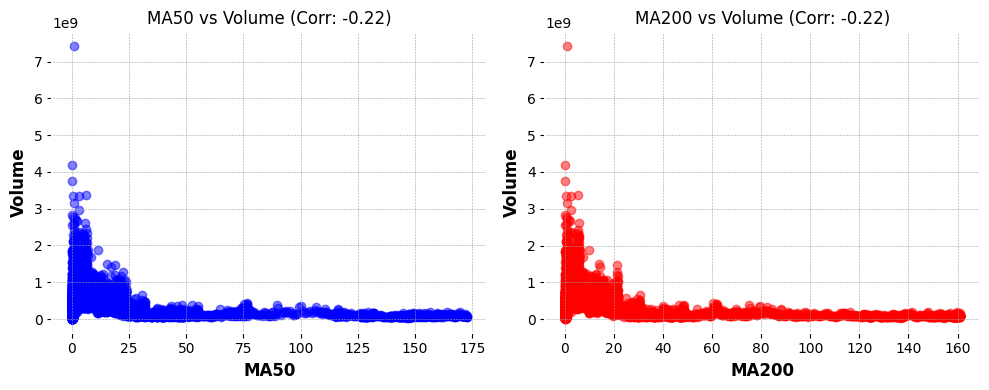

In [18]:
#Techniques statistiques avancées
def moving_average_convolve(signal, window_size):
    window = np.ones(window_size) / window_size
    return np.convolve(signal, window, mode='valid')

prices = df['Close'].values
volumes = df['Volume'].values

ma50_conv = moving_average_convolve(prices, 50)
ma200_conv = moving_average_convolve(prices, 200)

plt.figure(figsize=(14, 6))
plt.plot(df.index[49:], ma50_conv, label="MA50 (Via Convolve)", color="blue")
plt.plot(df.index[199:], ma200_conv, label="MA200 (Via Convolve)", color="red")
plt.title("Moyennes mobiles calculées par Convolution (NumPy)")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.show()

volumes_50 = volumes[49:]
corr_matrix_50 = np.corrcoef(ma50_conv, volumes_50)
corr_50 = corr_matrix_50[0, 1]

volumes_200 = volumes[199:]
corr_matrix_200 = np.corrcoef(ma200_conv, volumes_200)
corr_200 = corr_matrix_200[0, 1]

print("--- Analyse des Corrélations (NumPy) ---")
print(f"Corrélation entre MA50 et Volume (Période courte/moyenne) : {corr_50:.4f}")
print(f"Corrélation entre MA200 et Volume (Période longue) : {corr_200:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(ma50_conv, volumes_50, alpha=0.5, color="blue")
plt.title(f"MA50 vs Volume (Corr: {corr_50:.2f})")
plt.xlabel("MA50")
plt.ylabel("Volume")

plt.subplot(1, 2, 2)
plt.scatter(ma200_conv, volumes_200, alpha=0.5, color="red")
plt.title(f"MA200 vs Volume (Corr: {corr_200:.2f})")
plt.xlabel("MA200")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

Eplication du code pour l'étape 1 et 2
L'exploration initiale du jeu de données montre que les données d'Apple (AAPL) couvrent une large période historique sans aucune valeur manquante (0 valeur nulle détectée), ce qui garantit la fiabilité de notre analyse.

La conversion de la colonne Date en index temporel permet de structurer nos données de manière chronologique. Sur les graphiques générés :

Le graphique des prix montre une tendance globale fortement haussière à long terme, caractéristique des grandes valeurs technologiques de la période.

Le graphique des volumes met en évidence des pics d'activité massifs. Ces pics coïncident souvent avec des périodes de forte volatilité ou des annonces de résultats trimestriels.

Le graphique en chandeliers permet d'observer la volatilité quotidienne sur les 100 derniers jours : la longueur des mèches (hautes et basses) indique les batailles de prix intra-journalières entre acheteurs et vendeurs. 

Eplication du code pour l'étape 3
Les statistiques descriptives de base nous donnent des repères essentiels sur l'action Apple : la moyenne, la médiane et l'écart-type (qui mesure le risque ou la volatilité historique de l'action).

Pour analyser la tendance sans le "bruit" des fluctuations quotidiennes, nous avons tracé deux moyennes mobiles :

La MA50 (courte période) réagit rapidement aux changements récents du marché.

La MA200 (longue période) représente la tendance de fond de l'action.

Analyse visuelle : Lorsque le cours réel ou la MA50 se situe nettement au-dessus de la MA200, le titre est dans une phase haussière saine (Bull Market). Les croisements entre ces deux courbes (comme le Golden Cross ou le Death Cross) agissent historiquement comme des signaux d'achat ou de vente pour les investisseurs.

Explication du code pour l'étape 4
1. Comparaison des moyennes (Test t de Student)Le test t appliqué aux années 2020 et 2022 affiche une p-value extrêmement proche de 0 (inférieure à notre seuil $\alpha = 5\%$). 
Conclusion : Nous rejetons l'hypothèse nulle ($H_0$). La différence de prix moyen entre ces deux années est statistiquement significative. Cela confirme qu'Apple a franchi un palier de valorisation structurel entre ces deux périodes (marquées par l'effet post-confinement et l'expansion de ses services).

2. Test de normalité des rendementsLe test statistique de normalité renvoie une p-value inférieure à 0.05. Conclusion : Les rendements quotidiens d'Apple ne suivent pas une loi normale parfaite.En observant l'histogramme, on remarque un phénomène classique en finance : la distribution présente des "queues épaisses" (fat tails) et un pic plus pointu. Cela signifie que les mouvements extrêmes (krachs ou hausses spectaculaires) se produisent beaucoup plus fréquemment dans la réalité que ce que prédit la théorie mathématique de la loi normale.

Explication du code pour l'étape 5
1. Comparaison des moyennes (Test t de Student)Le test t appliqué aux années 2020 et 2022 affiche une p-value extrêmement p1. Approche par Convolution
L'utilisation de la fonction np.convolve de NumPy offre une alternative mathématique élégante au rolling de Pandas en traitant le cours de la bourse comme un signal numérique brut. Les courbes obtenues sont identiques, mais cette méthode démontre l'intérêt du traitement du signal appliqué à la finance quantitative.

2. Analyse des corrélations (Prix vs Volume)
Les coefficients de corrélation calculés avec np.corrcoef et les nuages de points associés nous révèlent la structure du marché :

Si la corrélation est faible (proche de 0), cela montre que les volumes de transactions ne dépendent pas linéairement du niveau du prix de l'action. Des volumes gigantesques peuvent s'échanger aussi bien à des prix bas (panique) qu'à des prix hauts (euphorie).

Le graphique Scatter Plot montre la dispersion de ces comportements, confirmant que le volume est un indicateur de l'émotion et de la liquidité du marché, plutôt qu'un reflet direct du prix.

RESUME GLOBAL
Ce mini-projet d'analyse de données financières sur l'action Apple a permis de lier la manipulation technique de données aux théories de la finance de marché. Voici les grandes conclusions à retenir :

Croissance et Volatilité : L'analyse descriptive et graphique montre une progression historique remarquable de l'action. Cependant, l'écart-type élevé souligne que cette hausse s'est faite au prix d'une volatilité intra-journalière et moyen terme non négligeable.

Pertinence des Indicateurs Temporels : Les moyennes mobiles (MA50 et MA200) ont prouvé leur efficacité pour lisser le "bruit" quotidien et identifier les tendances lourdes. L'implémentation par convolution via NumPy a démontré qu'une action boursière peut être modélisée avec succès comme un signal numérique.

Anomalies des Marchés Financiers : Le rejet de l'hypothèse de normalité sur les rendements quotidiens confirme empiriquement le concept de "queues épaisses" (fat tails). Les modèles mathématiques standards sous-estiment les risques de mouvements extrêmes sur le titre Apple.

Déconnexion Prix/Volume : L'analyse des corrélations met en évidence que le volume de transactions obéit à des dynamiques de liquidité et d'actualités (pics de volume) plutôt qu'à une relation linéaire avec le niveau absolu des